# Grid Behavior Overview

3 × 2 figure (methods × environments) overlaying:
- **Node colour** — substation action frequency, mean over seeds (white → red)
- **Edge colour** — mean ρ at failure, mean over seeds (green → red)

Both colorbars are shared globally across all six panels.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

import numpy as np
import grid2op

from analysis.cross_method.loader import load_method
from visualization import GridPlottingArgs, visualize_grid

# Import matplotlib AFTER project modules — they call matplotlib.use("Agg") at
# import time, which overrides %matplotlib inline when set earlier.
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
%matplotlib inline

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-23 10:44:14,322	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-07-23 10:44:18,188	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
ROOT = Path("../../results")
OUT_DIR = ROOT / "cross_env_grid_overview"
OUT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ["RAPPO", "GNN baseline", "MLP baseline"]
ENV_ORDER    = ["bus14", "bus36"]

ENV_CFG: dict = {
    "bus14": {
        "env_name": "l2rpn_case14_sandbox_test",
        "methods": {
            "RAPPO":   ROOT / "2026_07_20_IEEE14/rappo_multiseed_gcnconv",
            "GNN baseline": ROOT / "2026_07_20_IEEE14/ppo_gnn_gcnconv",
            "MLP baseline": ROOT / "2026_07_20_IEEE14/ppo_mlp",
        },
    },
    "bus36": {
        "env_name": "l2rpn_wcci_2020_test",
        "methods": {
            "RAPPO":   ROOT / "2026_07_20_IEEE36/rappo_multiseed",
            "GNN baseline": ROOT / "2026_07_20_IEEE36/ppo_gnn_gcnconv",
            "MLP baseline": ROOT / "2026_07_20_IEEE36/ppo_mlp",
        },
    },
}

## Load per-seed analysis data

In [3]:
# data[env_label][method_label] = MethodData
data: dict = {}
g2op_envs: dict = {}

for env_label, cfg in ENV_CFG.items():
    data[env_label] = {}
    g2op_envs[env_label] = grid2op.make(cfg["env_name"])
    for method_label, method_path in cfg["methods"].items():
        md = load_method(method_label, method_path)
        data[env_label][method_label] = md
        print(
            f"{env_label}/{method_label}: "
            f"{md.n_seeds} seeds, {md.n_sub} substations, {md.n_lines} lines"
        )

  No rho_at_failure for CustomPPO_RARL_5887369_1b111_2026-07-18_21-30-16, falling back to mean_rho_per_line
  No rho_at_failure for CustomPPO_GNN_5917591_13dda_2026-07-20_03-05-20, falling back to mean_rho_per_line
  No rho_at_failure for CustomPPO_MLP_5917598_1b19e_2026-07-20_03-05-32, falling back to mean_rho_per_line


bus14/RAPPO: 5 seeds, 14 substations, 20 lines
bus14/GNN baseline: 5 seeds, 14 substations, 20 lines
bus14/MLP baseline: 5 seeds, 14 substations, 20 lines
bus36/RAPPO: 5 seeds, 36 substations, 59 lines
bus36/GNN baseline: 5 seeds, 36 substations, 59 lines
bus36/MLP baseline: 5 seeds, 36 substations, 59 lines


## Save aggregated metrics

In [4]:
for env_label in ENV_ORDER:
    for method_label in METHOD_ORDER:
        md = data[env_label][method_label]
        stem = f"{env_label}_{method_label}".replace("-", "").replace(" ", "_")
        out_path = OUT_DIR / f"{stem}_metrics.npz"
        np.savez(
            out_path,
            mean_action_freq = md.action_freqs.mean(axis=0),
            std_action_freq  = md.action_freqs.std(axis=0),
            mean_rho         = md.mean_rhos.mean(axis=0),
            std_rho          = md.mean_rhos.std(axis=0),
            n_seeds          = np.array(md.n_seeds),
        )
        print(f"Stats for {env_label} and method {method_label}")
        print(f"{md.mean_rhos.mean()} +- {md.mean_rhos.std()}")
        print(f"Saved {out_path.name}")

Stats for bus14 and method RAPPO
0.5246232748031616 +- 0.22111637890338898
Saved bus14_RAPPO_metrics.npz
Stats for bus14 and method GNN baseline
0.5316274762153625 +- 0.21369394659996033
Saved bus14_GNN_baseline_metrics.npz
Stats for bus14 and method MLP baseline
0.5259215235710144 +- 0.18852195143699646
Saved bus14_MLP_baseline_metrics.npz
Stats for bus36 and method RAPPO
0.49179694056510925 +- 0.2315523475408554
Saved bus36_RAPPO_metrics.npz
Stats for bus36 and method GNN baseline
0.49197614192962646 +- 0.23248817026615143
Saved bus36_GNN_baseline_metrics.npz
Stats for bus36 and method MLP baseline
0.4919763207435608 +- 0.23145700991153717
Saved bus36_MLP_baseline_metrics.npz


## Compute global colour bounds

In [18]:
all_mean_freqs = [
    data[e][m].action_freqs.mean(axis=0)
    for e in ENV_ORDER for m in METHOD_ORDER
]
all_mean_rhos = [
    data[e][m].mean_rhos.mean(axis=0)
    for e in ENV_ORDER for m in METHOD_ORDER
]

freq_vmax = max(float(a.max()) for a in all_mean_freqs)
freq_vmax = max(freq_vmax, 1e-6)

rho_vmax = max(float(a.max()) for a in all_mean_rhos)
rho_vmax = max(rho_vmax, 1.0)  # always extend to at least the thermal limit

node_cmap = plt.cm.PuBu
edge_cmap = plt.cm.RdYlGn_r
node_norm = mcolors.Normalize(vmin=0.0, vmax=freq_vmax)
edge_norm = mcolors.Normalize(vmin=0.0, vmax=rho_vmax)

print(f"Action frequency  vmax : {freq_vmax:.4f}")
print(f"Mean ρ at failure vmax : {rho_vmax:.4f}")

Action frequency  vmax : 0.5931
Mean ρ at failure vmax : 1.1471


## Draw 3 × 2 figure

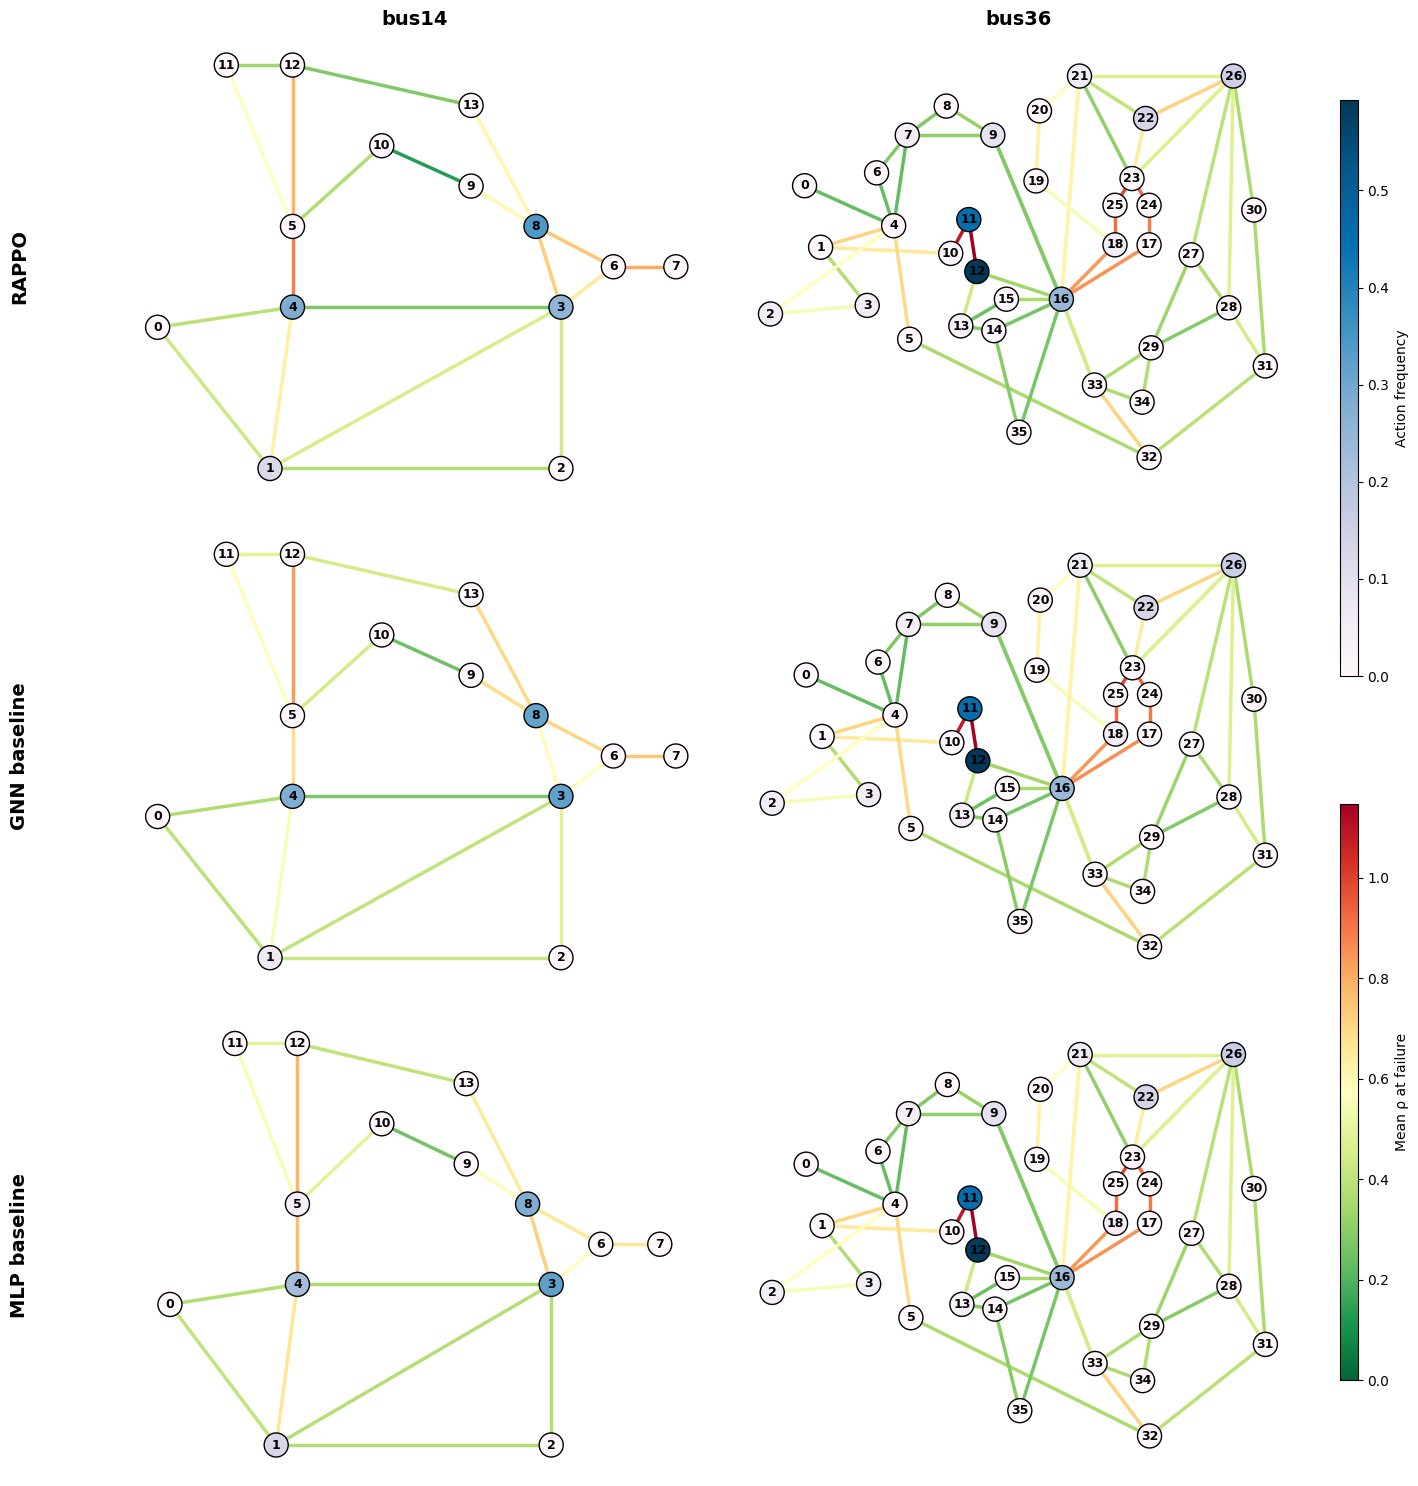

Saved to ../../results/cross_env_grid_overview


In [19]:
N_ROWS = len(METHOD_ORDER)  # 3
N_COLS = len(ENV_ORDER)     # 2

plt.style.use("default")

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 16))
fig.subplots_adjust(
    left=0.08, right=0.87,
    top=0.94,  bottom=0.04,
    hspace=0.06, wspace=0.04,
)

for row_idx, method_label in enumerate(METHOD_ORDER):
    for col_idx, env_label in enumerate(ENV_ORDER):
        ax = axes[row_idx, col_idx]
        md = data[env_label][method_label]
        env = g2op_envs[env_label]

        sub_freq = md.action_freqs.mean(axis=0)
        mean_rho = md.mean_rhos.mean(axis=0)

        node_colors = [mcolors.to_hex(node_cmap(node_norm(float(v)))) for v in sub_freq]
        line_colors = [mcolors.to_hex(edge_cmap(edge_norm(float(v)))) for v in mean_rho]

        visualize_grid(
            GridPlottingArgs(
                env=env,
                node_colors=node_colors,
                line_colors=line_colors,
                line_widths=[2.5] * env.n_line,
                node_size=300,
                font_size=9,
                font_color="black",
                show_legend=False,
            ),
            ax=ax,
        )

        # Remove ticks and spines without touching title or other text artists
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if row_idx == 0:
            ax.set_title(env_label, fontsize=14, fontweight="bold", pad=8)

# Row labels — positioned after layout is resolved
# fig.canvas.draw()
for row_idx, method_label in enumerate(METHOD_ORDER):
    bbox = axes[row_idx, 0].get_position()
    y_center = (bbox.y0 + bbox.y1) / 2
    fig.text(
        0.01, y_center, method_label,
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        rotation=90,
    )

# Two vertical colorbars on the far right — outside the column area so it is
# visually clear that both scales are shared across all six panels.
node_sm = plt.cm.ScalarMappable(cmap=node_cmap, norm=node_norm)
edge_sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)

cbar_freq_ax = fig.add_axes([0.89, 0.54, 0.012, 0.36])  # upper: action frequency
cbar_rho_ax  = fig.add_axes([0.89, 0.10, 0.012, 0.36])  # lower: congestion

fig.colorbar(node_sm, cax=cbar_freq_ax, orientation="vertical", label="Action frequency")
fig.colorbar(edge_sm, cax=cbar_rho_ax, orientation="vertical", label="Mean ρ at failure")

fig.savefig(OUT_DIR / "grid_behavior_overview.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT_DIR / "grid_behavior_overview.svg", bbox_inches="tight")
plt.show()
print(f"Saved to {OUT_DIR}")